In [103]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.cluster import KMeans


In [104]:
df = pd.read_csv('Data06JoMix.csv')

In [105]:
df.isnull().sum()

Country            0
Age                0
Height_cm          0
Weight_kg          0
Sex                0
Weight_in_Words    0
dtype: int64

In [106]:
unique_values_per_column = df.apply(lambda col: col.unique())
print(unique_values_per_column)

Country            [USA, Algeria, Jordan, United Arab Emirates, T...
Age                [29, 58, 57, 24, 49, 30, 63, 41, 18, 27, 22, 5...
Height_cm          [183.1, 188.3, 170.0, 194.4, 185.5, 167.4, 176...
Weight_kg          [78.7, 93.6, 112.0, 93.8, 113.5, 96.6, 107.4, ...
Sex                                                   [Male, Female]
Weight_in_Words    [seventy-eight, ninety-three, one hundred and ...
dtype: object


In [ ]:

# Define features
numeric_features = ['Age', 'Height_cm', 'Weight_kg']
categorical_features = ['Sex']

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)],
    remainder='drop'
)

preprocessed_data = preprocessor.fit_transform(df)

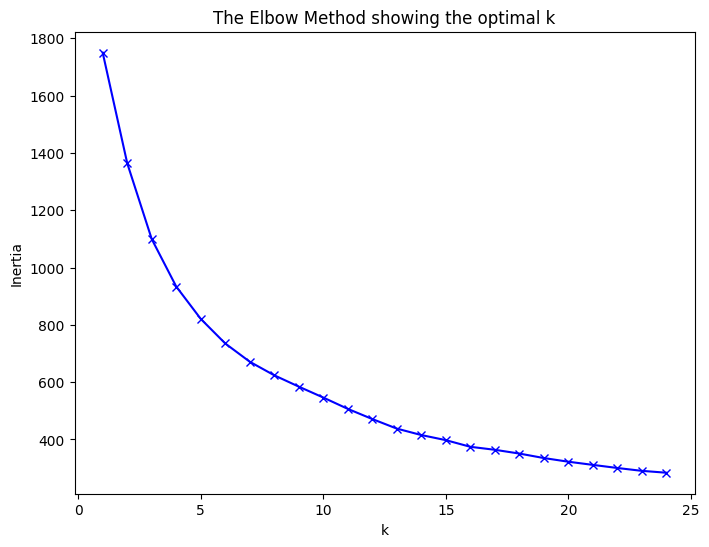

In [108]:
# Calculate inertia for a range of K values
inertia = []
K = range(1, 25)
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(preprocessed_data)
    inertia.append(kmeans.inertia_)

# Plot the elbow curve
plt.figure(figsize=(8, 6))
plt.plot(K, inertia, 'bx-')
plt.xlabel('k')
plt.ylabel('Inertia')
plt.title('The Elbow Method showing the optimal k')
plt.show()

In [109]:
inertia_distances = np.diff(inertia)

# Print the distances
print("Inertia distances:")
for i, dist in enumerate(inertia_distances):
    print(f"K={i+1} to K={i+2}: {dist}")


Inertia distances:
K=1 to K=2: -385.5469540056379
K=2 to K=3: -264.8212110571808
K=3 to K=4: -165.70328832984387
K=4 to K=5: -112.8437933768098
K=5 to K=6: -85.83946147913366
K=6 to K=7: -63.754527836097736
K=7 to K=8: -47.331818824863035
K=8 to K=9: -39.5499850288129
K=9 to K=10: -38.08077321986616
K=10 to K=11: -39.543946922938744
K=11 to K=12: -35.507947306497954
K=12 to K=13: -33.36522920265628
K=13 to K=14: -22.509143541298158
K=14 to K=15: -17.763329102299508
K=15 to K=16: -23.257767840894815
K=16 to K=17: -10.420786578769139
K=17 to K=18: -13.160068274235698
K=18 to K=19: -15.663518143825456
K=19 to K=20: -12.819400342800293
K=20 to K=21: -11.056475033281401
K=21 to K=22: -10.833384231837954
K=22 to K=23: -9.991238743487656
K=23 to K=24: -6.539842278991102


## Fine-tuning K-Means

The elbow plot above helps us find the optimal number of clusters (K). The `inertia_` attribute of the KMeans model represents the sum of squared distances of samples to their closest cluster center. We are looking for the 'elbow' point on the plot, where the rate of decrease in inertia slows down significantly. This point suggests a good trade-off between the number of clusters and the compactness of the clusters.

Based on the plot, the elbow appears to be at **K=3**. After this point, the drop in inertia is not as significant.

Other hyperparameters that can be tuned for KMeans include:

- **`init`**: The method for initialization. The default is 'k-means++', which is generally a good choice. Other options include 'random'.
- **`n_init`**: The number of times the KMeans algorithm will be run with different centroid seeds. The final results will be the best output of `n_init` consecutive runs in terms of inertia. The default is 10, which is what we used. Increasing this can lead to more stable results, but also increases computation time.
- **`max_iter`**: The maximum number of iterations of the KMeans algorithm for a single run.
- **`tol`**: The relative tolerance with regard to the Frobenius norm of the difference in the cluster centers of two consecutive iterations to declare convergence.

## Silhouette Score
While the elbow method is a good heuristic, it can sometimes be ambiguous. For a more robust way to choose *k*, consider using the Silhouette Score. It measures how similar a data point is to its own cluster compared to other clusters. A higher silhouette score indicates better-defined clusters. The *k* with the highest silhouette score is often the best choice.

Based on the plot, the Silhouette Score appears to be greatest at **K=14**. After this point, the score seems to be oscillating around a score of .275.


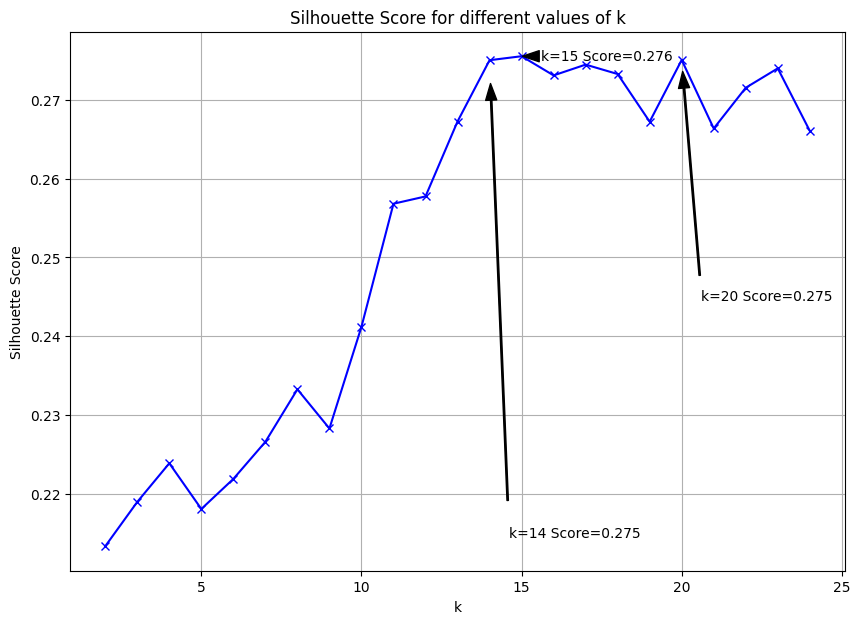

In [110]:
from sklearn.metrics import silhouette_score
silhouette_scores = []
K = range(2, 25)
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(preprocessed_data)
    score = silhouette_score(preprocessed_data, kmeans.labels_)
    silhouette_scores.append(score)

# Top 3 Indicies
scores_array = np.array(silhouette_scores)
top3_indices = np.argsort(scores_array)[-3:]

# Plot the silhouette scores
plt.figure(figsize=(10, 7))
plt.plot(K, silhouette_scores, 'bx-')
plt.xlabel('k')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score for different values of k')
plt.grid(True)

y_offset_step = 0.03

for idx, i in enumerate(reversed(top3_indices)):
    k_value = K[i]
    score_value = scores_array[i]

    y_text_position = score_value - (idx * y_offset_step)
    x_text_position = k_value + 0.6

    plt.annotate(f'k={k_value} Score={score_value:.3f}',
                 xy=(k_value, score_value),
                 xytext=(x_text_position, y_text_position),
                 arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=8),
                 horizontalalignment='left',
                 verticalalignment='center')
plt.show()
